In [35]:
!pip install -q datasets transformers accelerate scikit-learn pandas matplotlib seaborn
!pip install -q tokenizers


# Imports

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)
from datasets import Dataset, DatasetDict
import torch
import torch.nn.functional as F
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)

# Loading Data Frame

Here we load the data in mem

In [ ]:
df = pd.read_csv("mtsamples.csv")  # <-- change filename if needed

# Sanity check on data volume and strcture
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Peek at the first few rows verifying parsing
print("\nFirst 3 rows:")
df.head(2)

Shape: (4999, 6)

Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

First 3 rows:


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."


# Dropping null transcripts

In [38]:
df = df.dropna(subset=["transcription"])
print(f"\nShape after dropping null transcriptions: {df.shape}")


Shape after dropping null transcriptions: (4966, 6)


As we can see from above the data frame shape didn't change, the data has no null transcripts.

In [39]:
df["medical_specialty"] = df["medical_specialty"].str.strip()

# Class distribution

## Unique classification and freq

Here we map medical specialities with their frequency in the dataset.

In [40]:
class_counts = df["medical_specialty"].value_counts()
print("\n--- Class Distribution ---")
print(class_counts)
print(f"\nTotal unique specialties: {class_counts.nunique()}")


--- Class Distribution ---
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Psychiatry / Psychology            53
Office Notes                       50
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosm

## Merging Classes

We will merge the medical specialities which have less than 15 records to "Others".

In [41]:
MIN_SAMPLES = 15
rare_classes = class_counts[class_counts < MIN_SAMPLES].index.tolist()

print(f"\n--- Classes being merged into 'Other' (< {MIN_SAMPLES} samples) ---")
for cls in rare_classes:
    print(f"  {cls}: {class_counts[cls]} samples")

df["label"] = df["medical_specialty"].apply(
    lambda x: "Other" if x in rare_classes else x
)


--- Classes being merged into 'Other' (< 15 samples) ---
  Chiropractic: 14 samples
  Diets and Nutritions: 10 samples
  Rheumatology: 10 samples
  Speech - Language: 9 samples
  Autopsy: 8 samples
  Lab Medicine - Pathology: 8 samples
  Allergy / Immunology: 7 samples
  Hospice - Palliative Care: 6 samples


## Final Class Distribution

### Text based

In [42]:
final_counts = df["label"].value_counts()
print(f"\n--- Final Class Distribution ({final_counts.nunique()} classes) ---")
print(final_counts)


--- Final Class Distribution (32 classes) ---
label
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Other                              72
Pediatrics - Neonatal              70
Pain Management                    61
Psychiatry / Psychology            53
Office Notes                       50
Podiatry                           47
Dermatology                        

### Visual Representation

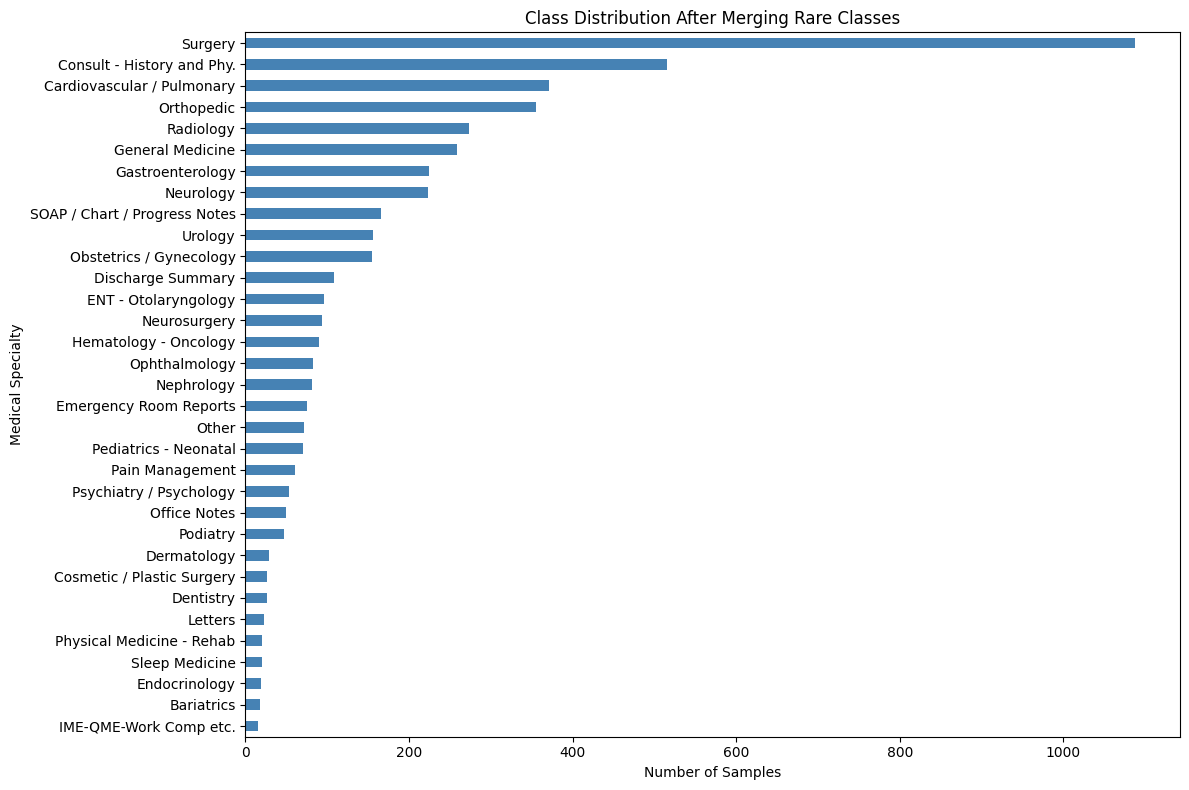

In [43]:
plt.figure(figsize=(12, 8))
final_counts.plot(kind="barh", color="steelblue")
plt.xlabel("Number of Samples")
plt.ylabel("Medical Specialty")
plt.title("Class Distribution After Merging Rare Classes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Label Mapping

In [ ]:
# Get sorted unique labels to keep IDs consistent acros runs
unique_labels = sorted(df["label"].unique())

# Bidirectional maps for encoding and decoding labels
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

df["label_id"] = df["label"].map(label2id)

print(f"\n--- Label Mappings ({len(label2id)} classes) ---")
for label, idx in sorted(label2id.items(), key=lambda x: x[1]):
    print(f"  {idx}: {label}")


--- Label Mappings (33 classes) ---
  0: Bariatrics
  1: Cardiovascular / Pulmonary
  2: Consult - History and Phy.
  3: Cosmetic / Plastic Surgery
  4: Dentistry
  5: Dermatology
  6: Discharge Summary
  7: ENT - Otolaryngology
  8: Emergency Room Reports
  9: Endocrinology
  10: Gastroenterology
  11: General Medicine
  12: Hematology - Oncology
  13: IME-QME-Work Comp etc.
  14: Letters
  15: Nephrology
  16: Neurology
  17: Neurosurgery
  18: Obstetrics / Gynecology
  19: Office Notes
  20: Ophthalmology
  21: Orthopedic
  22: Other
  23: Pain Management
  24: Pediatrics - Neonatal
  25: Physical Medicine - Rehab
  26: Podiatry
  27: Psychiatry / Psychology
  28: Radiology
  29: SOAP / Chart / Progress Notes
  30: Sleep Medicine
  31: Surgery
  32: Urology


In [45]:
df["text_length"] = df["transcription"].apply(lambda x: len(str(x).split()))
print("\n--- Transcription Length Stats (word count) ---")
print(df["text_length"].describe())


--- Transcription Length Stats (word count) ---
count    4966.000000
mean      465.448852
std       316.386344
min         1.000000
25%       241.000000
50%       398.000000
75%       615.000000
max      3029.000000
Name: text_length, dtype: float64


# Transcription Length

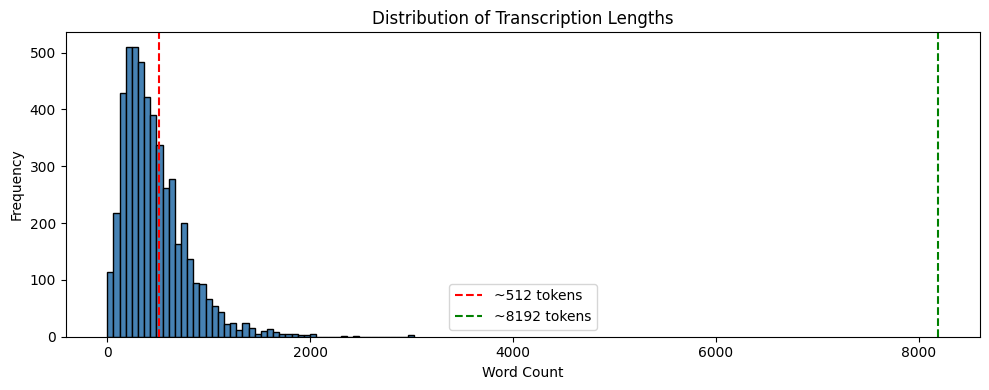

In [46]:
plt.figure(figsize=(10, 4))
plt.hist(df["text_length"], bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Distribution of Transcription Lengths")
plt.axvline(x=512, color="red", linestyle="--", label="~512 tokens")
plt.axvline(x=8192, color="green", linestyle="--", label="~8192 tokens")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
print(f"   Total samples: {len(df)}")
print(f"   Total classes: {len(label2id)}")

   Total samples: 4966
   Total classes: 33


We will only keep the columns that we need.

In [48]:
df_model = df[["transcription", "label", "label_id"]].copy()
df_model = df_model.rename(columns={"transcription": "text", "label_id": "labels"})
df_model["text"] = df_model["text"].astype(str)

print(f"Total samples: {len(df_model)}")

Total samples: 4966


# Training Data

In [ ]:
# Initial split to get out 80% for training.
train_df, temp_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model["labels"]
)

# Splitting the remaining 20% in half to create distinct validation and test sets.
# This gives us a final 80/10/10 ratio to tune hyperparameters and then do a final unbiased evaluation.
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["labels"]
)

In [50]:
print(f"\nTrain: {len(train_df)} samples")
print(f"Val:   {len(val_df)} samples")
print(f"Test:  {len(test_df)} samples")


Train: 3972 samples
Val:   497 samples
Test:  497 samples


## Stratification Verification

In [51]:
print("\n--- Class distribution check (top 5 classes) ---")
top5 = train_df["label"].value_counts().head(5).index.tolist()
for cls in top5:
    tr = (train_df["label"] == cls).sum()
    va = (val_df["label"] == cls).sum()
    te = (test_df["label"] == cls).sum()
    print(f"  {cls}: Train={tr}, Val={va}, Test={te}")


--- Class distribution check (top 5 classes) ---
  Surgery: Train=870, Val=109, Test=109
  Consult - History and Phy.: Train=413, Val=52, Test=51
  Cardiovascular / Pulmonary: Train=297, Val=37, Test=37
  Orthopedic: Train=284, Val=35, Test=36
  Radiology: Train=218, Val=28, Test=27


# Convert to HuggingFace Datasets

In [ ]:
# Convert our Pandas DataFrames into Hugging Face Dataset objects for the trainer.
train_dataset = Dataset.from_pandas(train_df[["text", "labels"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["text", "labels"]], preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[["text", "labels"]], preserve_index=False)

In [ ]:
# Combining individual splits into a single DatasetDict object.
dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

print("\n--- Dataset ---")
print(dataset)


--- Dataset ---
DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 3972
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 497
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 497
    })
})


# Loading Model

In [54]:
MODEL_NAME = "thomas-sounack/BioClinical-ModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\nTokenizer loaded: {MODEL_NAME}")
print(f"Max model length: {tokenizer.model_max_length}")


Tokenizer loaded: thomas-sounack/BioClinical-ModernBERT-base
Max model length: 8192


In [ ]:
# Here we process the text into a format the model can actually ingest.
# 2048 context length covers majority of the transcripts
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=2048,
    )


print("\nTokenizing datasets... (this may take a minute)")
tokenized_dataset = dataset.map(tokenize_fn, batched=True, batch_size=32)


Tokenizing datasets... (this may take a minute)


Map:   0%|          | 0/3972 [00:00<?, ? examples/s]

Map:   0%|          | 0/497 [00:00<?, ? examples/s]

Map:   0%|          | 0/497 [00:00<?, ? examples/s]

Removing raw text column

In [56]:
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

In [57]:
tokenized_dataset.set_format("torch")

print("\n--- Tokenized Dataset ---")
print(tokenized_dataset)
print("\nSample keys:", list(tokenized_dataset["train"][0].keys()))


--- Tokenized Dataset ---
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 3972
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 497
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 497
    })
})

Sample keys: ['labels', 'input_ids', 'attention_mask']


# Tokens analysis


--- Token Length Stats (Train) ---
  Mean:   718 tokens
  Median: 642 tokens
  Max:    2048 tokens
  % at max (2048): 1.6%


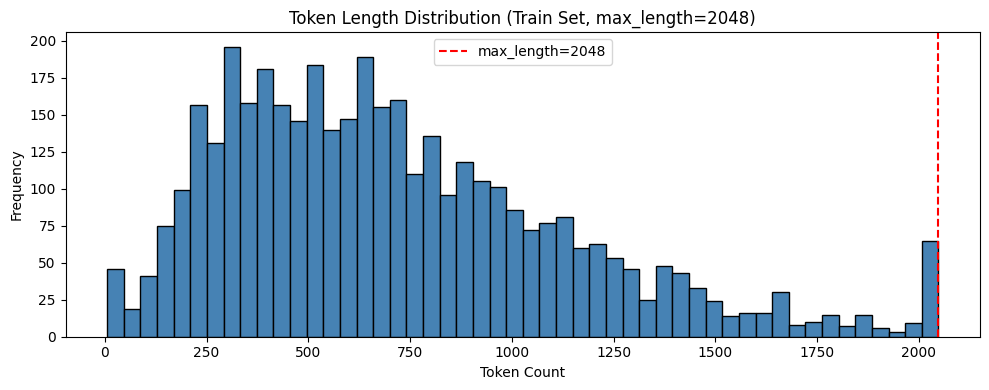

In [ ]:
# Iterating through the train set to calculate the actual number of tokens ussed
train_lengths = []
for example in tokenized_dataset["train"]:
    attn = example["attention_mask"]
    real_len = attn.sum().item()
    train_lengths.append(real_len)

print(f"\n--- Token Length Stats (Train) ---")
lengths_arr = np.array(train_lengths)
print(f"  Mean:   {lengths_arr.mean():.0f} tokens")
print(f"  Median: {np.median(lengths_arr):.0f} tokens")
print(f"  Max:    {lengths_arr.max()} tokens")
print(f"  % at max (2048): {(lengths_arr == 2048).mean() * 100:.1f}%")

plt.figure(figsize=(10, 4))
plt.hist(train_lengths, bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.title("Token Length Distribution (Train Set, max_length=2048)")
plt.axvline(x=2048, color="red", linestyle="--", label="max_length=2048")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Check for a GPU to handle the heavy lifting or otherwise, fall back to the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# If we're on CUDA then get the hardware specs to make sure we have enough VRAM for the 2048 token length.
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


# Computing class weights to handle imbalance

In [ ]:
train_labels = train_df["labels"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels,
)

# Converting weights to a tensor and then push them to the GPU so they can be applied to the loss function later.
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("\n--- Class Weights (top 5 highest) ---")
weight_pairs = [(id2label[i], w) for i, w in enumerate(class_weights)]
weight_pairs_sorted = sorted(weight_pairs, key=lambda x: x[1], reverse=True)
for label, weight in weight_pairs_sorted[:5]:
    print(f"  {label}: {weight:.2f}")

print(f"\n--- Class Weights (top 5 lowest) ---")
for label, weight in weight_pairs_sorted[-5:]:
    print(f"  {label}: {weight:.2f}")


--- Class Weights (top 5 highest) ---
  IME-QME-Work Comp etc.: 9.26
  Bariatrics: 8.60
  Endocrinology: 8.02
  Sleep Medicine: 7.52
  Physical Medicine - Rehab: 7.08

--- Class Weights (top 5 lowest) ---
  Radiology: 0.55
  Orthopedic: 0.42
  Cardiovascular / Pulmonary: 0.41
  Consult - History and Phy.: 0.29
  Surgery: 0.14


# Loading model

In [ ]:
NUM_LABELS = len(label2id)

# Initialising the classification head on top of the pre trained ModernBERT.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    problem_type="single_label_classification",
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Gradient Checkpointing

In [ ]:
# Trading off some compute time for memory efficiency. 
# This lets us fit the 2048 token sequences into VRAM by not storing all intermediate activations.
model.gradient_checkpointing_enable()

print(f"\nModel loaded: {MODEL_NAME}")
print(f"Number of labels: {NUM_LABELS}")
print(f"Gradient checkpointing: Enabled")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")



Model loaded: thomas-sounack/BioClinical-ModernBERT-base
Number of labels: 33
Gradient checkpointing: Enabled
Total parameters: 149,630,241
Trainable parameters: 149,630,241


# Custom Trainer and Metric Func

In [ ]:
# Custom Trainer subclass to inject class weights into the loss calculation.
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# To track how well the model is actually learning during training.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average="macro", zero_division=0)
    f1_weighted = f1_score(labels, predictions, average="weighted", zero_division=0)
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

# Training Arguments

In [64]:
training_args = TrainingArguments(
    output_dir="./bioclinical_modernbert_specialty",

    # Training duration
    num_train_epochs=5,

    # Batch size & memory optimization
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,  # effective batch size = 1 * 8 = 8

    # Mixed precision for memory savings
    fp16=True,

    # Learning rate schedule
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",

    # Evaluation & saving
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,  # keep only the 2 best checkpoints

    # Logging
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",

    # Misc
    seed=42,
    remove_unused_columns=True,
    dataloader_pin_memory=True,
)

print("\n--- Training Configuration ---")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"  Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  FP16: {training_args.fp16}")
print(f"  Warmup ratio: {training_args.warmup_ratio}")
print(f"  Scheduler: {training_args.lr_scheduler_type}")
print(f"  Best model metric: {training_args.metric_for_best_model}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



--- Training Configuration ---
  Epochs: 5
  Batch size: 1
  Gradient accumulation: 8
  Effective batch size: 8
  Learning rate: 2e-05
  FP16: True
  Warmup ratio: 0.1
  Scheduler: SchedulerType.COSINE
  Best model metric: f1_macro


In [65]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

print("\n Starting training...\n")
train_result = trainer.train()

# --- 3j. Print training summary ---
print("\n--- Training Complete ---")
print(f"  Total steps: {train_result.global_step}")
print(f"  Training loss: {train_result.training_loss:.4f}")
metrics = train_result.metrics
for k, v in metrics.items():
    print(f"  {k}: {v}")


 Starting training...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,15.427922,1.758789,0.382294,0.156263,0.311181
2,11.948350,1.585444,0.336016,0.209778,0.304233
3,11.073547,1.582886,0.291751,0.229180,0.270753
4,8.878773,1.682978,0.239437,0.206149,0.229165
5,8.229662,1.753119,0.211268,0.202680,0.204462


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- Training Complete ---
  Total steps: 2485
  Training loss: 11.5616
  train_runtime: 9239.3113
  train_samples_per_second: 2.15
  train_steps_per_second: 0.269
  total_flos: 2.707562094944256e+16
  train_loss: 11.561629346390845
  epoch: 5.0


In [86]:
trainer.save_model("./bioclinical_modernbert_specialty/best_model")
tokenizer.save_pretrained("./bioclinical_modernbert_specialty/best_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bioclinical_modernbert_specialty/best_model/tokenizer_config.json',
 './bioclinical_modernbert_specialty/best_model/tokenizer.json')

# Evaluation and Analysis

## Evaluation of Test Set

In [ ]:
print("Evaluating on test set...\n")
test_results = trainer.evaluate(tokenized_dataset["test"])

print("--- Test Set Results ---")
for k, v in test_results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

🔍 Evaluating on test set...



--- Test Set Results ---
  eval_loss: 1.4729
  eval_accuracy: 0.3139
  eval_f1_macro: 0.2194
  eval_f1_weighted: 0.2914
  eval_runtime: 78.6783
  eval_samples_per_second: 6.3170
  eval_steps_per_second: 6.3170
  epoch: 5.0000


## Predictions for more analysis

In [68]:
predictions = trainer.predict(tokenized_dataset["test"])
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

## Classification Report

In [69]:
target_names = [id2label[i] for i in range(NUM_LABELS)]

print("\n--- Classification Report ---\n")
report = classification_report(
    true_labels,
    pred_labels,
    target_names=target_names,
    zero_division=0,
)
print(report)


--- Classification Report ---

                               precision    recall  f1-score   support

                   Bariatrics       0.00      0.00      0.00         2
   Cardiovascular / Pulmonary       0.32      0.46      0.38        37
   Consult - History and Phy.       0.25      0.31      0.28        51
   Cosmetic / Plastic Surgery       0.00      0.00      0.00         2
                    Dentistry       0.33      0.67      0.44         3
                  Dermatology       0.00      0.00      0.00         3
            Discharge Summary       0.57      0.36      0.44        11
         ENT - Otolaryngology       0.29      0.44      0.35         9
       Emergency Room Reports       0.50      0.38      0.43         8
                Endocrinology       0.00      0.00      0.00         2
             Gastroenterology       0.35      0.50      0.42        22
             General Medicine       0.18      0.08      0.11        26
        Hematology - Oncology       0.17    

## Confusion Matix

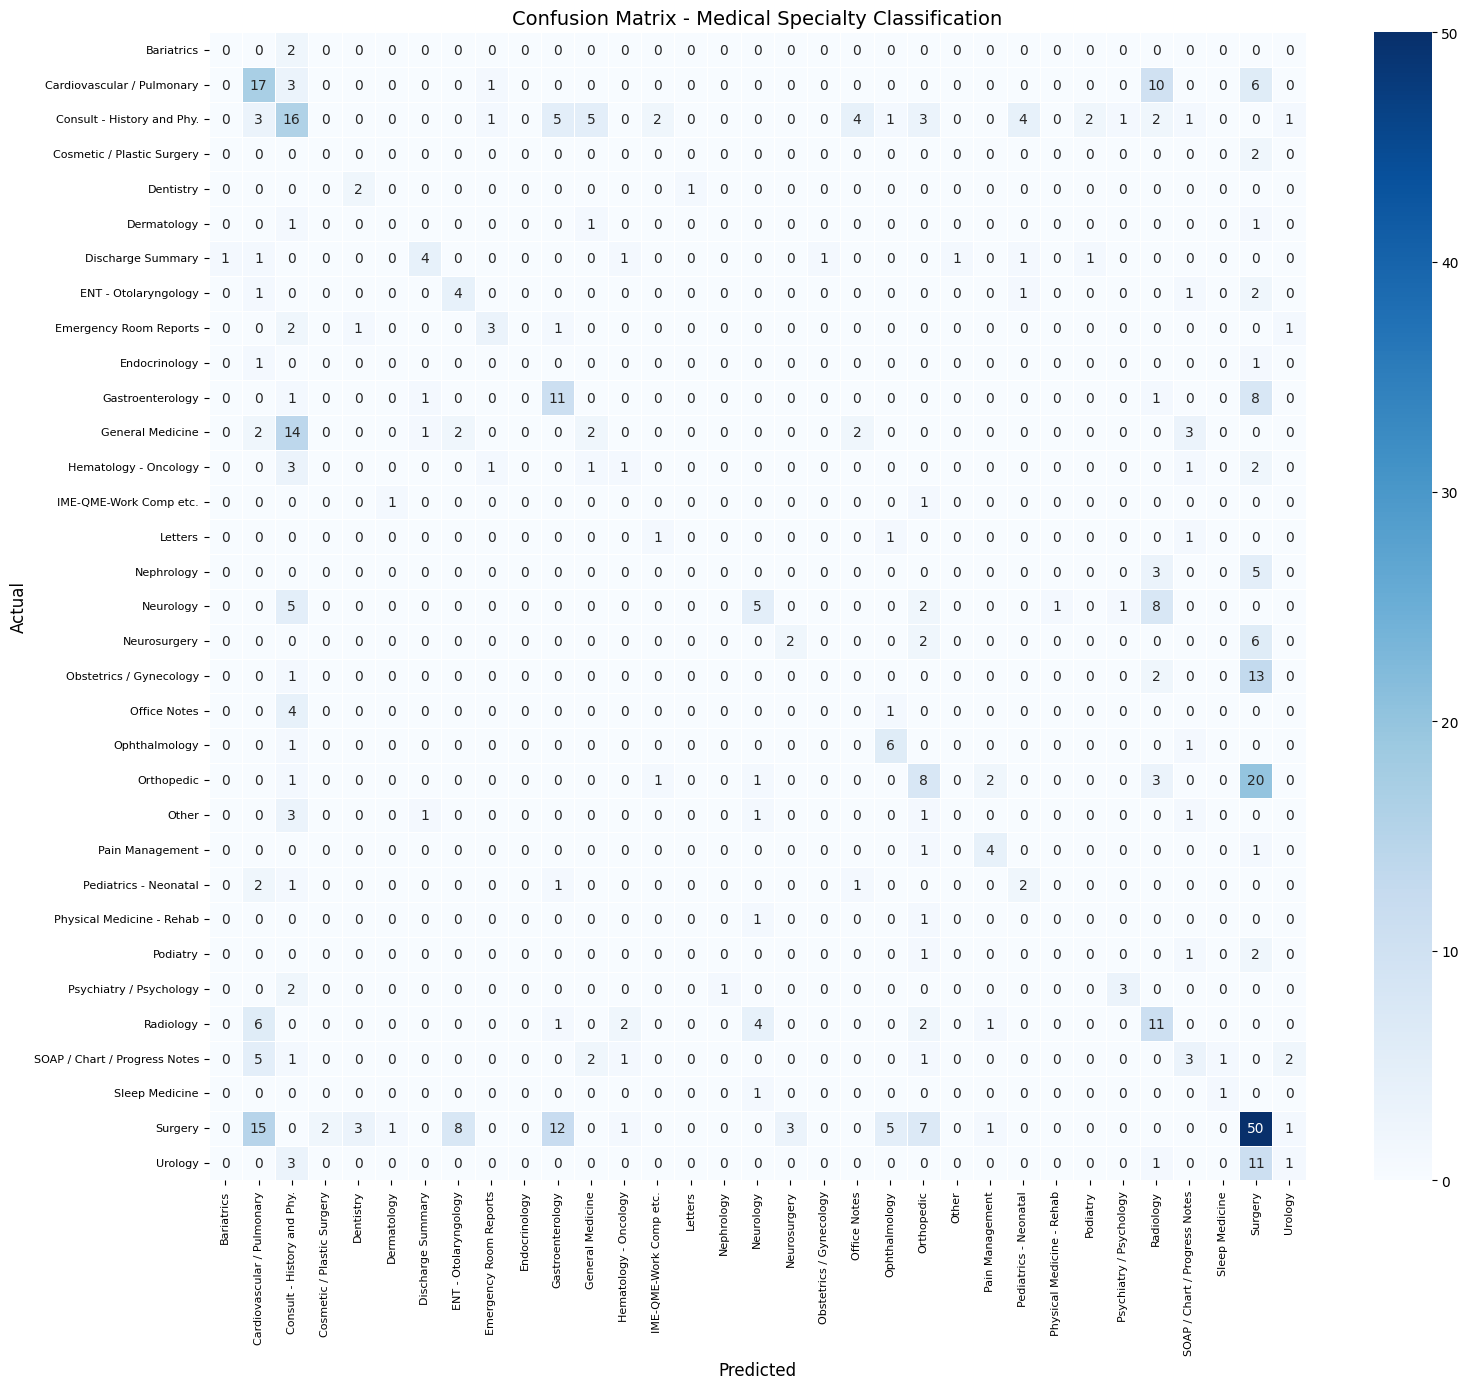

In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.5,
)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix - Medical Specialty Classification", fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

## Per Class Breakdown

In [72]:
print("\n--- Per-Class Accuracy ---\n")
per_class_acc = []
for i in range(NUM_LABELS):
    mask = true_labels == i
    if mask.sum() > 0:
        class_acc = (pred_labels[mask] == true_labels[mask]).mean()
        per_class_acc.append((id2label[i], class_acc, mask.sum()))
    else:
        per_class_acc.append((id2label[i], 0.0, 0))

# Sort by accuracy (ascending to see worst performers first)
per_class_acc_sorted = sorted(per_class_acc, key=lambda x: x[1])

print(f"{'Specialty':<45} {'Accuracy':>10} {'Samples':>10}")
print("-" * 67)
for label, acc, count in per_class_acc_sorted:
    bar = "█" * int(acc * 20)
    print(f"{label:<45} {acc:>9.1%} {count:>10}  {bar}")


--- Per-Class Accuracy ---

Specialty                                       Accuracy    Samples
-------------------------------------------------------------------
Bariatrics                                         0.0%          2  
Cosmetic / Plastic Surgery                         0.0%          2  
Dermatology                                        0.0%          3  
Endocrinology                                      0.0%          2  
IME-QME-Work Comp etc.                             0.0%          2  
Letters                                            0.0%          3  
Nephrology                                         0.0%          8  
Obstetrics / Gynecology                            0.0%         16  
Office Notes                                       0.0%          5  
Other                                              0.0%          7  
Physical Medicine - Rehab                          0.0%          2  
Podiatry                                           0.0%          4  
Urology

## Confused Pairs

In [73]:
print("\n--- Top 10 Most Confused Pairs ---\n")
confused_pairs = []
for i in range(NUM_LABELS):
    for j in range(NUM_LABELS):
        if i != j and cm[i][j] > 0:
            confused_pairs.append((id2label[i], id2label[j], cm[i][j]))

confused_pairs_sorted = sorted(confused_pairs, key=lambda x: x[2], reverse=True)

print(f"{'Actual':<35} {'Predicted As':<35} {'Count':>6}")
print("-" * 78)
for actual, predicted, count in confused_pairs_sorted[:10]:
    print(f"{actual:<35} {predicted:<35} {count:>6}")


--- Top 10 Most Confused Pairs ---

Actual                              Predicted As                         Count
------------------------------------------------------------------------------
Orthopedic                          Surgery                                 20
Surgery                             Cardiovascular / Pulmonary              15
General Medicine                    Consult - History and Phy.              14
Obstetrics / Gynecology             Surgery                                 13
Surgery                             Gastroenterology                        12
Urology                             Surgery                                 11
Cardiovascular / Pulmonary          Radiology                               10
Gastroenterology                    Surgery                                  8
Neurology                           Radiology                                8
Surgery                             ENT - Otolaryngology                     8


# Summary

In [76]:
overall_acc = accuracy_score(true_labels, pred_labels)
f1_mac = f1_score(true_labels, pred_labels, average="macro", zero_division=0)
f1_wt = f1_score(true_labels, pred_labels, average="weighted", zero_division=0)

print("\n" + "=" * 50)
print("         FINAL TEST SET SUMMARY")
print("=" * 50)
print(f"  Accuracy:        {overall_acc:.4f} ({overall_acc:.1%})")
print(f"  F1 (macro):      {f1_mac:.4f}")
print(f"  F1 (weighted):   {f1_wt:.4f}")
print(f"  Total classes:   {NUM_LABELS}")
print(f"  Test samples:    {len(true_labels)}")
print("=" * 50)


         FINAL TEST SET SUMMARY
  Accuracy:        0.3139 (31.4%)
  F1 (macro):      0.2194
  F1 (weighted):   0.2914
  Total classes:   33
  Test samples:    497


# Prediction

## Model Load

In [79]:
MODEL_PATH = "./bioclinical_modernbert_specialty/best_model"

inf_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
inf_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inf_model.to(device)
inf_model.eval()

print(f"Model loaded from: {MODEL_PATH}")
print(f"Device: {device}")
print(f"Number of labels: {inf_model.config.num_labels}")

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Model loaded from: ./bioclinical_modernbert_specialty/best_model
Device: cuda
Number of labels: 33


In [80]:
def predict_specialty(text, top_k=3):
    """
    Predict medical specialty from transcription text.
    Returns top_k predictions with confidence scores.
    """
    inputs = inf_tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=2048,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        outputs = inf_model(**inputs)
        logits = outputs.logits
        probs = F.softmax(logits, dim=-1)

    top_probs, top_indices = torch.topk(probs, top_k, dim=-1)

    results = []
    for prob, idx in zip(top_probs[0], top_indices[0]):
        label = inf_model.config.id2label[idx.item()]
        results.append({
            "specialty": label,
            "confidence": prob.item(),
        })

    return results

In [81]:
def print_prediction(text, results):
    print("\n" + "=" * 60)
    print("INPUT TEXT (first 200 chars):")
    print(f"  {text[:200]}...")
    print("\nPREDICTIONS:")
    for i, r in enumerate(results):
        bar = "█" * int(r["confidence"] * 30)
        print(f"  {i+1}. {r['specialty']:<40} {r['confidence']:>6.1%}  {bar}")
    print("=" * 60)

In [83]:
sample_1 = """
SUBJECTIVE: This 23-year-old white female presents with complaint of allergies.
She used to have allergies when she lived in Seattle but she thinks they are worse here.
In the past, she has tried Claritin, and Zyrtec. Both worked for short time but then
seemed to lose effectiveness. She has used Allegra also. She does have asthma but
does not require daily medication for this.
OBJECTIVE: Vitals: Weight was 130 pounds and blood pressure 124/78.
HEENT: Her throat was mildly erythematous without exudate. Nasal mucosa was
erythematous and swollen.
ASSESSMENT: Allergic rhinitis.
PLAN: She will try Zyrtec instead of Allegra again. Samples of Nasonex given.
"""

In [84]:
results_1 = predict_specialty(sample_1)
print_prediction(sample_1, results_1)


INPUT TEXT (first 200 chars):
  
SUBJECTIVE: This 23-year-old white female presents with complaint of allergies.
She used to have allergies when she lived in Seattle but she thinks they are worse here.
In the past, she has tried Cla...

PREDICTIONS:
  1. SOAP / Chart / Progress Notes             40.3%  ████████████
  2. Consult - History and Phy.                16.8%  █████
  3. General Medicine                          14.2%  ████
